# Machine Learning Application

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, SubsetRandomSampler


In [2]:
#read in cleaned data and split into training validation and test sets for linear regression
#I am going to predict different things in my models so I will have to redo this later for different target variables
thyr = pd.read_csv('.Data//Cleaned_thyroidcancer_data.csv')
thyr.columns

Index(['Age', 'Gender', 'Country', 'Ethnicity', 'Family_History',
       'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity',
       'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size',
       'Thyroid_Cancer_Risk', 'Diagnosis', 'Gender_Female', 'Gender_Male',
       'Ethnicity_African', 'Ethnicity_Asian', 'Ethnicity_Caucasian',
       'Ethnicity_Hispanic', 'Ethnicity_Middle Eastern',
       'Thyroid_Cancer_Risk Encoded', 'Diagnosis Encoded'],
      dtype='object')

In [3]:
thyr.head()

,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,...,Diagnosis,Gender_Female,Gender_Male,Ethnicity_African,Ethnicity_Asian,Ethnicity_Caucasian,Ethnicity_Hispanic,Ethnicity_Middle Eastern,Thyroid_Cancer_Risk Encoded,Diagnosis Encoded
0,66,Male,Russia,Caucasian,0,1,0,0,0,0,...,Benign,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0
1,29,Male,Germany,Hispanic,0,1,0,0,0,0,...,Benign,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0
2,86,Male,Nigeria,Caucasian,0,0,0,0,0,0,...,Benign,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0
3,75,Female,India,Asian,0,0,0,0,0,0,...,Benign,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0
4,35,Female,Germany,African,1,1,0,0,0,0,...,Benign,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2,0


In [4]:
thyr.shape

(212691, 25)

Since the data set is so large in my test train split I am going to reduce the size of my training sets to allow the code to run faster. I have already tried most of the code without taking this into account so if the results become drastically different I may change this decision.

## Logistic Regression

In [5]:
numeric = thyr.select_dtypes(include=np.number)

In [6]:
from sklearn.model_selection import train_test_split
X = numeric.drop(['Thyroid_Cancer_Risk Encoded', 'Diagnosis Encoded'], axis=1) #Risk and diagnosis are both variables to predict
#For my logistic regression I am going to predict diagnosis between benign and malignant
y = numeric['Diagnosis Encoded']
#First split into training/validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = .4, random_state=1)
#Then split into training and validation, since dataset is large this will be more efficient that k-fold cross validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = .5, random_state=1)

I am going to be performing normal logistic regression as well as logistic regression with kernel tricks, first I will scale the data to reduce issues with weights of variables.

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform X_train
X_train = scaler.fit_transform(X_train)

# Transform X_val and X_test using the same scaler
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, classification_report, accuracy_score

C = .01
#regularization hyperparameter
model_log = LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=10000, class_weight={0:1, 1:2})
model_log.fit(X_train, y_train)

y_pred_proba_log = model_log.predict_proba(X_val)[:, 1]
y_pred_val = model_log.predict(X_val)
print(classification_report(y_val, y_pred_val))

# Calculate log los
loss_log = log_loss(y_val, y_pred_proba_log)
print(f"Log Loss: {loss_log}")

#Compute training accuracy
train_pred = model_log.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training accuracy: {train_accuracy:.2f}")

              precision    recall  f1-score   support

           0       0.82      0.89      0.85     48865
           1       0.48      0.35      0.40     14942

    accuracy                           0.76     63807
   macro avg       0.65      0.62      0.63     63807
weighted avg       0.74      0.76      0.74     63807

Log Loss: 0.5562142852466607
Training accuracy: 0.76


In [11]:
from sklearn.metrics import confusion_matrix, classification_report
#Look at confusion matrix on test set
y_pred = model_log.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Confusion Matrix:
[[57661  7656]
 [12737  7023]]
Accuracy: 0.76


the true positives (the way confusion matrix works with these labels) are true predictions that a tumor was benign so false positives are malginant tumors being assigned as benign

After about 15 minutes of messing with the hyperparameters and l1 vs l2 loss I could tell that there wasn't going to be a substantial improvement. Log loss of .55 is as low as I got which is not very good. I was able to get a lower loss without adding weight to the cancerous class but this resulted in a recall of .09 for that lable which is very bad. As evidenced by the confusion matrix there are substantial numbers of false negatives and false positives. In this context a false positive is more harmful than a false negative when predicting whether a tumor is cancerous so I am going to try adding kernel tricks with the logistic regression and see if we can get lower log loss and fewer false positives. It is also possible that the patterns in the data are too complex and require something more computationally intense like a neural network but hopefully kernelizing will provide some improvement.

To do this I will be using built in kernel approximations because computing a kernel matrix would be too computationally expensive with this size of data set.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.kernel_approximation import Nystroem

#hyperparameters
gamma=.01
C=100
n=200

pipeline = Pipeline([
    ('nystroem', Nystroem(kernel='rbf', gamma=gamma, n_components=n, random_state=3)),
    ('logreg', LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=10000))
])

pipeline.fit(X_train, y_train)
y_pred_val = pipeline.predict(X_val)
print(classification_report(y_val, y_pred_val))

pred_p = pipeline.predict_proba(X_val)
loss = log_loss(y_val, pred_p)
print(f'Log loss: {loss}')

#Compute training accuracy
train_pred = pipeline.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training accuracy: {train_accuracy:.2f}")

              precision    recall  f1-score   support

           0       0.82      0.96      0.89     48865
           1       0.71      0.32      0.44     14942

    accuracy                           0.81     63807
   macro avg       0.76      0.64      0.66     63807
weighted avg       0.79      0.81      0.78     63807

Log loss: 0.4795694662656283
Training accuracy: 0.81


In [13]:
#Look at confusion matrix on test set
y_pred = pipeline.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Confusion Matrix:
[[62622  2695]
 [13438  6322]]
Accuracy: 0.81


When messing with this rbf kernel I found that increasing the regularization played a more important role in decreasing the log loss when editing hyperparameters, it also appears that the kernel itself helps project some of the patterns in the data leading to an increase in accuracy. However we do see a decrease in the recall for cancerous tumors which is not ideal. Changing class_weight also does not fix the recall issue like in the plain regression and just makes the log loss and f1 scores slightly decreased.

In [14]:
#hyperparameters
gamma=.01
coef0=.1
C=1
n=250

pipeline = Pipeline([
    #Using sigmoid kernel to hopefully make the process closer to what a single layer neural network would do
    ('nystroem', Nystroem(kernel='sigmoid', gamma=gamma, coef0=coef0, n_components=n, random_state=3)),
    ('logreg', LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=10000))
])

pipeline.fit(X_train, y_train)
y_pred_val = pipeline.predict(X_val)
print(classification_report(y_val, y_pred_val))

pred_p = pipeline.predict_proba(X_val)
loss = log_loss(y_val, pred_p)
print(f'Log loss: {loss}')

#Compute training accuracy
train_pred = pipeline.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training accuracy: {train_accuracy:.2f}")

              precision    recall  f1-score   support

           0       0.82      0.96      0.89     48865
           1       0.71      0.31      0.44     14942

    accuracy                           0.81     63807
   macro avg       0.76      0.64      0.66     63807
weighted avg       0.79      0.81      0.78     63807

Log loss: 0.481642976102576
Training accuracy: 0.81


In [15]:
#Look at confusion matrix on test set
y_pred = pipeline.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Confusion Matrix:
[[62641  2676]
 [13465  6295]]
Accuracy: 0.81


My logistic regression was not as good as I hoped at trying to identify cancerousness but before moving on I want to try keeping risk factor in the data set and making doing logistic regression with it included. It should be the best predictor of whether a tumor is cancerous and I felt that including it was cheap because it would add too much context but given the less than ideal performance I want to investigate if it makes a substantial difference.

In [16]:
X = numeric.drop(['Diagnosis Encoded'], axis=1)
#For my logistic regression I am going to predict diagnosis between benign and malignant
y = numeric['Diagnosis Encoded']
#First split into training/validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = .4, random_state=1)
#Then split into training and validation, since dataset is large this will be more efficient that k-fold cross validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = .5, random_state=1)

scaler = StandardScaler()

# Fit the scaler on the training data and transform X_train
X_train = scaler.fit_transform(X_train)

# Transform X_val and X_test using the same scaler
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [17]:
C = .01
#regularization hyperparameter
model_log = LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=10000, class_weight={0:1, 1:2})
model_log.fit(X_train, y_train)

y_pred_proba_log = model_log.predict_proba(X_val)[:, 1]
y_pred_val = model_log.predict(X_val)

# Calculate log los
loss_log = log_loss(y_val, y_pred_proba_log)
print(f"Log Loss: {loss_log}")
print(classification_report(y_val, y_pred_val))

#Compute training accuracy
train_pred = model_log.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training accuracy: {train_accuracy:.2f}")

Log Loss: 0.5142350454857555
              precision    recall  f1-score   support

           0       0.85      0.93      0.89     48865
           1       0.68      0.45      0.54     14942

    accuracy                           0.82     63807
   macro avg       0.76      0.69      0.72     63807
weighted avg       0.81      0.82      0.81     63807

Training accuracy: 0.82


In [18]:
#Look at confusion matrix on test set
y_pred = model_log.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Confusion Matrix:
[[60878  4439]
 [10706  9054]]
Accuracy: 0.82


While my predictions still aren't great they are certainly improved from what they were earlier so I believe that leaving cancer risk out of my initial regression was not a good decision and negatively impacted the accuracy substantially. I tried changing the regularization constant but my log loss on the validation set was minimizing to around .47 which is still not very good. I tried using the class_weight parameter as well because the data is imbalanced but this resulted in worse predictions as well.

It is also relevant to look at the prediction power associated with each feature now that we added back "Cancer Risk" to the training data

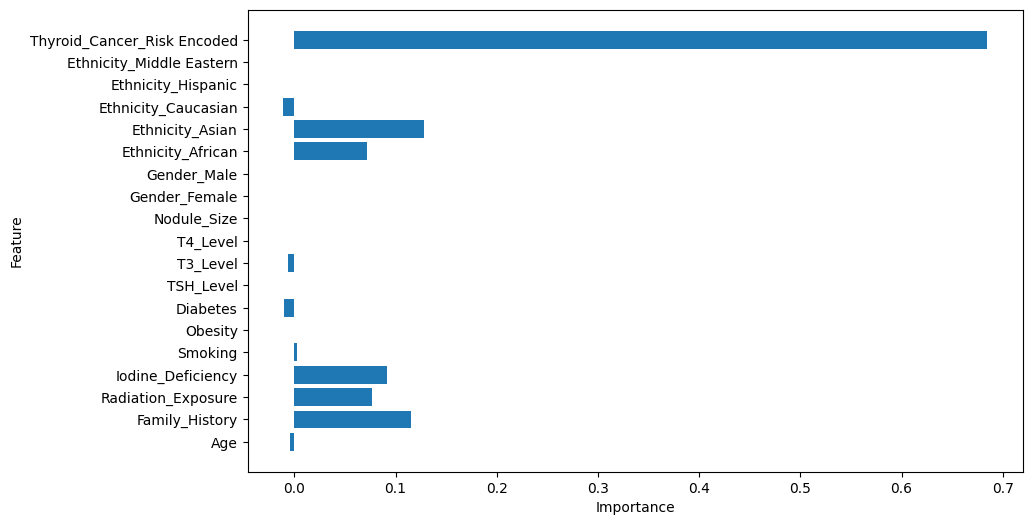

In [19]:
feat_imp = model_log.coef_[0]
plt.figure(figsize=(10,6))
plt.barh(X.columns, feat_imp)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

This graph clearly shows why the logistic regression improved substantially once adding back the thyroid risk column as it has an extremely high feature importance of near 1. Since it is so important I also want to rerun the regressions with kernel tricks and see if the improvements carry over through them as well.

In [22]:
#hyperparameters
gamma=.001
C=10
n=200

pipeline = Pipeline([
    ('nystroem', Nystroem(kernel='rbf', gamma=gamma, n_components=n, random_state=3)),
    ('logreg', LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=10000))
])

pipeline.fit(X_train, y_train)
y_pred_val = pipeline.predict(X_val)
print(classification_report(y_val, y_pred_val))

pred_p = pipeline.predict_proba(X_val)
loss = log_loss(y_val, pred_p)
print(f'Log loss: {loss}')

#Compute training accuracy
train_pred = pipeline.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training accuracy: {train_accuracy:.2f}")

              precision    recall  f1-score   support

           0       0.85      0.94      0.89     48865
           1       0.71      0.45      0.55     14942

    accuracy                           0.83     63807
   macro avg       0.78      0.70      0.72     63807
weighted avg       0.82      0.83      0.81     63807

Log loss: 0.45573176717267355
Training accuracy: 0.83


In [23]:
#Look at confusion matrix on test set
y_pred = pipeline.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Confusion Matrix:
[[61457  3860]
 [10816  8944]]
Accuracy: 0.83


In [25]:
#hyperparameters
gamma=.001
coef0=.1
C=10
n=250

pipeline = Pipeline([
    #Using sigmoid kernel to hopefully make the process closer to what a single layer neural network would do
    ('nystroem', Nystroem(kernel='sigmoid', gamma=gamma, coef0=coef0, n_components=n, random_state=3)),
    ('logreg', LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=10000))
])

pipeline.fit(X_train, y_train)
y_pred_val = pipeline.predict(X_val)
print(classification_report(y_val, y_pred_val))

pred_p = pipeline.predict_proba(X_val)
loss = log_loss(y_val, pred_p)
print(f'Log loss: {loss}')

#Compute training accuracy
train_pred = pipeline.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training accuracy: {train_accuracy:.2f}")

              precision    recall  f1-score   support

           0       0.84      0.95      0.89     48865
           1       0.71      0.41      0.52     14942

    accuracy                           0.82     63807
   macro avg       0.77      0.68      0.71     63807
weighted avg       0.81      0.82      0.80     63807

Log loss: 0.46441806803291175
Training accuracy: 0.82


In [26]:
#Look at confusion matrix on test set
y_pred = pipeline.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Confusion Matrix:
[[61761  3556]
 [11519  8241]]
Accuracy: 0.82


As expected both kernelized version improved over their prior when adding back the cancer risk column. However the recall is still not improving even with changes to the class_weight parameter although there is now a very small disparity between the non kernelized version

## Support Vector Machine

For my SVM and all techniques going forward I will be using the training set with "Cancer Risk" in it to try and get as accurate a prediction as possible when determining whether a tumor is cancerous or not

In [27]:
X = numeric.drop(['Diagnosis Encoded'], axis=1)
#For my logistic regression I am going to predict diagnosis between benign and malignant
y = numeric['Diagnosis Encoded']
#First split into training/validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = .6, random_state=1)
#Then split into training and validation, since dataset is large this will be more efficient that k-fold cross validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = .9, random_state=1)

scaler = StandardScaler()

# Fit the scaler on the training data and transform X_train
X_train = scaler.fit_transform(X_train)

# Transform X_val and X_test using the same scaler
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [28]:
X_train.shape

(8507, 19)

For the SVM section I split down my data into a very small training set because the cells were taking so long to run due to the time complexity of SVMs so I can hopefully get results without having to wait 30 minutes a cell

In [29]:
from sklearn.svm import SVC

In [32]:
#First using no kernel and just scikit learn's SVC function


#hyperparamers
C=10 #Regularization

SVM = SVC(kernel='linear', C=C, cache_size=3000, class_weight='balanced')
SVM.fit(X_train, y_train)

val_pred = SVM.predict(X_val)

accuracy = accuracy_score(y_val, val_pred)
print(f"Validation accuracy: {accuracy:.2f}")
print(classification_report(y_val, val_pred))

#Compute training accuracy
train_pred = SVM.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training accuracy: {train_accuracy:.2f}")

Validation accuracy: 0.73
              precision    recall  f1-score   support

           0       0.85      0.79      0.82     58672
           1       0.44      0.54      0.48     17897

    accuracy                           0.73     76569
   macro avg       0.64      0.66      0.65     76569
weighted avg       0.75      0.73      0.74     76569

Training accuracy: 0.74


In [33]:
test_pred = SVM.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)
print(f"Test Accuracy: {test_accuracy:.2f}")
print("Test Classification Report:")
print(classification_report(y_test, test_pred))

# Compute the confusion matrix
cm = confusion_matrix(y_test, test_pred)
print("Confusion Matrix:")
print(cm)

Test Accuracy: 0.73
Test Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82     98005
           1       0.44      0.54      0.48     29610

    accuracy                           0.73    127615
   macro avg       0.65      0.67      0.65    127615
weighted avg       0.76      0.73      0.74    127615

Confusion Matrix:
[[77703 20302]
 [13639 15971]]


The accuracy of the linear SVM is not that good but it gets the highest recall on cancerous tumors so far. Since the classes are so imbalanced I had to set class weight to balanced to prevent it from predicting every point as the dominant class (benign)

In [34]:
#Next lets implement the rbf kernel, this is built in to the SVC function

#hyperparameters
C=10 #Regularization
gamma = .01  #Smoothness of classification border

rbf_SVM = SVC(kernel = 'rbf', C=C, gamma=gamma, cache_size=3000, class_weight='balanced')
rbf_SVM.fit(X_train, y_train)

val_pred = rbf_SVM.predict(X_val)

accuracy = accuracy_score(y_val, val_pred)
print(f"Validation accuracy: {accuracy:.2f}")
print(classification_report(y_val, val_pred))

#Compute training accuracy
train_pred = rbf_SVM.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training accuracy: {train_accuracy:.2f}")

Validation accuracy: 0.83
              precision    recall  f1-score   support

           0       0.85      0.94      0.89     58672
           1       0.70      0.45      0.55     17897

    accuracy                           0.83     76569
   macro avg       0.78      0.70      0.72     76569
weighted avg       0.81      0.83      0.81     76569

Training accuracy: 0.83


In [35]:
test_pred = rbf_SVM.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)
print(f"Test Accuracy: {test_accuracy:.2f}")
print("Test Classification Report:")
print(classification_report(y_test, test_pred))

# Compute the confusion matrix
cm = confusion_matrix(y_test, test_pred)
print("Confusion Matrix:")
print(cm)

Test Accuracy: 0.83
Test Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89     98005
           1       0.70      0.45      0.55     29610

    accuracy                           0.83    127615
   macro avg       0.77      0.70      0.72    127615
weighted avg       0.82      0.83      0.81    127615

Confusion Matrix:
[[92202  5803]
 [16205 13405]]


In [36]:
#Finally lets use a polynomial kernel in the same way and observe any changes

#hyperparameters
C=.01  #Regularization
gamma=.1 #Smoothness
degree=3 #Polynomial degree
coef0 = .1 #Independent term

poly_SVM = SVC(kernel='poly', C=C, gamma=gamma, degree=degree, coef0=coef0, class_weight='balanced')
poly_SVM.fit(X_train, y_train)

val_pred = poly_SVM.predict(X_val)

accuracy = accuracy_score(y_val, val_pred)
print(f"Validation accuracy: {accuracy:.2f}")
print(classification_report(y_val, val_pred))

#Compute training accuracy
train_pred = poly_SVM.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training accuracy: {train_accuracy:.2f}")

Validation accuracy: 0.82
              precision    recall  f1-score   support

           0       0.85      0.94      0.89     58672
           1       0.69      0.45      0.55     17897

    accuracy                           0.82     76569
   macro avg       0.77      0.69      0.72     76569
weighted avg       0.81      0.82      0.81     76569

Training accuracy: 0.83


In [37]:
test_pred = poly_SVM.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)
print(f"Test Accuracy: {test_accuracy:.2f}")
print("Test Classification Report:")
print(classification_report(y_test, test_pred))

# Compute the confusion matrix
cm = confusion_matrix(y_test, test_pred)
print("Confusion Matrix:")
print(cm)

Test Accuracy: 0.83
Test Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89     98005
           1       0.69      0.45      0.55     29610

    accuracy                           0.83    127615
   macro avg       0.77      0.70      0.72    127615
weighted avg       0.81      0.83      0.81    127615

Confusion Matrix:
[[91904  6101]
 [16149 13461]]


## Decision Tree

In [38]:
#Return to large training set for decision tree as it is less computationally expensive and will run just fine
X = numeric.drop(['Diagnosis Encoded'], axis=1)
#For my logistic regression I am going to predict diagnosis between benign and malignant
y = numeric['Diagnosis Encoded']
#First split into training/validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = .2, random_state=1)
#Then split into training and validation, since dataset is large this will be more efficient that k-fold cross validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = .2, random_state=1)

scaler = StandardScaler()

# Fit the scaler on the training data and transform X_train
X_train = scaler.fit_transform(X_train)

# Transform X_val and X_test using the same scaler
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [52]:
from sklearn.tree import DecisionTreeClassifier

#Hyperparameters
hyperparameters = {
    'criterion': 'gini',  # or 'entropy' for information gain
    'splitter': 'best',   # or 'random' for random splits
    'max_depth': 12,    # maximum depth of the tree (None means no limit)
    'min_samples_split': 2,  # minimum number of samples required to split a node
    'min_samples_leaf': 1,   # minimum number of samples required at a leaf node
    'min_weight_fraction_leaf': 0.0,  # minimum weighted fraction of the sum total of weights required at a leaf node
    'max_features': None,    # number of features to consider when looking for the best split (None means all features)
}
    
DTC = DecisionTreeClassifier(**hyperparameters, random_state=3)
DTC.fit(X_train, y_train)

val_pred = DTC.predict(X_val)

accuracy = accuracy_score(y_val, val_pred)
print(f"Validation Accuracy: {accuracy:.2f}")
print(classification_report(y_val, val_pred))

#Compute training accuracy
train_pred = DTC.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training accuracy: {train_accuracy:.2f}")

Validation Accuracy: 0.82
              precision    recall  f1-score   support

           0       0.85      0.94      0.89     26049
           1       0.68      0.44      0.54      7982

    accuracy                           0.82     34031
   macro avg       0.76      0.69      0.71     34031
weighted avg       0.81      0.82      0.81     34031

Training accuracy: 0.83


In [53]:
cm = confusion_matrix(y_val, val_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[24378  1671]
 [ 4451  3531]]


I had originally used no hyperparamter tuning because I wanted to see what the tree fully built on the training data would do and it ended up with an accuracy of only 70%. After adjusting parameters it obviously got worse on the training set but generalized much better as evidenced by the 82% validation accuracy

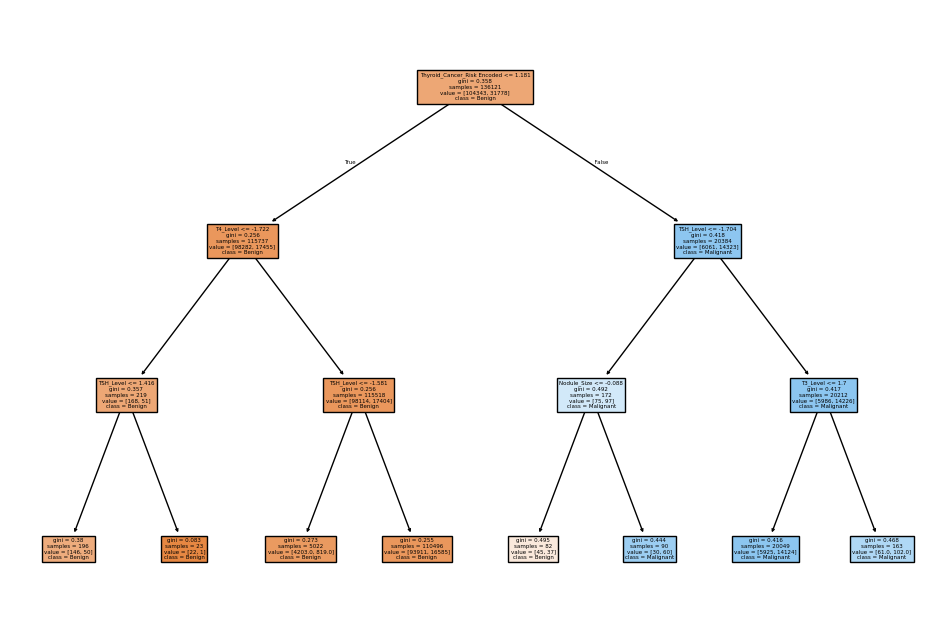

In [51]:
from sklearn.tree import plot_tree

DTCforgraph = DecisionTreeClassifier(criterion = 'gini', random_state=3, max_depth=3)
DTCforgraph.fit(X_train, y_train)
# Plot the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(DTCforgraph, filled=True, feature_names=X.columns.tolist(), class_names=['Benign', 'Malignant'])
plt.show()

In order to plot my tree I had to modify the DTC to have a max_depth of 3 because it is likely that my tree model with 70% accuracy is extremely deep since I did not place efficiency constraints on it due to a desire to push the accuracy as far as it can go. This plot of the tree gives a rough idea of what the upper levels of the tree from my full model look like.


Finally lets see how the fitted tree performs on the test data, I will once again fit it with no max_depth parameter

In [54]:

DTC.fit(X_train, y_train)

y_pred = DTC.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.83
              precision    recall  f1-score   support

           0       0.85      0.94      0.89     32804
           1       0.68      0.45      0.54      9735

    accuracy                           0.83     42539
   macro avg       0.77      0.69      0.72     42539
weighted avg       0.81      0.83      0.81     42539



In [55]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[30748  2056]
 [ 5365  4370]]


The accuracy, report and confusion matrix (in terms of proportions) are all extremely similar to what it got when predicting for the validation set. This suggests that the patterns in the data are likely consistent but that the decision tree wasn't able to fully capture some of the more complex patterns

## Random Forests

In [60]:
from sklearn.ensemble import RandomForestClassifier

#hyperparameters
n= 300
min_samples_split= 5 
min_samples_leaf= 4 
max_features= 'log2'
max_depth = 12

rf_model = RandomForestClassifier(random_state=3, n_estimators=n, min_samples_split=min_samples_split, max_depth=max_depth,
                                  min_samples_leaf=min_samples_leaf, max_features=max_features, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_val)

#Compute training accuracy
train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training accuracy: {train_accuracy:.2f}")

# Evaluate the model
print("Validation Accuracy:", accuracy_score(y_val, y_pred)) 
print("Classification Report:\n", classification_report(y_val, y_pred))

Training accuracy: 0.83
Validation Accuracy: 0.8248067938056478
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.89     26049
           1       0.70      0.45      0.55      7982

    accuracy                           0.82     34031
   macro avg       0.77      0.69      0.72     34031
weighted avg       0.81      0.82      0.81     34031



Once again accuracy in the low 80s with a mediocre recall, notable that by increasing the max depth the training accuracy can get above 90 but the validation accuracy stays in the below 83% range. Very similar to the results we got in our kernelized SVM

In [61]:
y_pred_test = rf_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_test)) 
print("Classification Report:\n", classification_report(y_test, y_pred_test))

Test Accuracy: 0.8297562237006042
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.89     32804
           1       0.70      0.46      0.55      9735

    accuracy                           0.83     42539
   macro avg       0.77      0.70      0.72     42539
weighted avg       0.82      0.83      0.82     42539



Once again very similar results with the test set as what we saw in the validation set.

## Neural Network

In [62]:
class BinaryLogisticRegression(nn.Module):
    def __init__(self, input_size):
        super(BinaryLogisticRegression, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)  # Hidden layer
        self.fc2 = nn.Linear(128, 64)          
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()           # Sigmoid activation

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)              
        x = self.sigmoid(x)          # Apply sigmoid activation
        return x

In [63]:
#train step function from project 2
def train_step(model, X_train, y_train, loss_fn, optimizer, device):
    # Move data to device
    X_train, y_train = X_train.to(device), y_train.to(device)
    
    # Set the model to training mode
    model.train()
    
    # Forward pass: compute predictions
    outputs = model(X_train)
    
    # Compute the loss
    loss = loss_fn(outputs, y_train)
    
    # Backward pass: compute gradients
    optimizer.zero_grad()  # Clear previous gradients
    loss.backward()        # Compute gradients
    optimizer.step()       # Update model parameters
    
    # Compute accuracy
    predicted = (outputs >= 0.375).float()  # Get the predicted class, more likely to predict cancerous to fix recall issue 
    correct = (predicted == y_train).sum().item()  # Count correct predictions
    accuracy = correct / y_train.size(0)  # Calculate accuracy
    
    # Return the loss and accuracy
    return loss.item(), accuracy

In [64]:
#Eval step from project 2
def evaluation_step(model, X_test, y_test, loss_fn, device):
    # Move data to device
    X_test, y_test = X_test.to(device), y_test.to(device)
    
    # Set the model to evaluation mode
    model.eval()
    
    # Disable gradient computation for evaluation
    with torch.no_grad():
        # Forward pass: compute predictions
        outputs = model(X_test)
        
        # Compute the loss
        loss = loss_fn(outputs, y_test)
        
        # Compute accuracy
        predicted = (outputs >= 0.375).float()  # Get the predicted class, more likely to predict cancerous to fix recall issue
        correct = (predicted == y_test).sum().item()  # Count correct predictions
        accuracy = correct / y_test.size(0)  # Calculate accuracy
    
    # Return the loss and accuracy
    return loss.item(), accuracy, predicted

In [65]:
#training function from project 2, modified to use multiple random seeds
def train_simple_model(X_train, y_train, X_test, y_test, random_seeds):
    # Make device
    device = "cpu" 
    if torch.cuda.is_available(): 
        device = "cuda"
    else:
        if torch.backends.mps.is_available():
            device = "mps" 
    for seed in random_seeds:
        seed_train_losses, seed_train_accuracies = [], []
        seed_test_losses, seed_test_accuracies = [], []
        torch.manual_seed(seed) # do not change this
        # Hyperparameters
        input_size = X_train.shape[1]  # Number of input features
        learning_rate = 0.015

        num_epochs = 35

        # Initialize the model, loss function, and optimizer
        model = BinaryLogisticRegression(input_size).to(device)
        loss_fn = nn.BCELoss() 
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        # Lists to store metrics
        train_losses, train_accuracies = [], []
        test_losses, test_accuracies = [], []

        # Move the entire dataset to the device
        X_train, y_train = X_train.to(device), y_train.to(device)
        X_test, y_test = X_test.to(device), y_test.to(device)

        # Training loop
        for epoch in range(num_epochs):
            # Train the model on the entire dataset
            train_loss, train_accuracy = train_step(model, X_train, y_train, loss_fn, optimizer, device)
            train_losses.append(train_loss)
            train_accuracies.append(train_accuracy)

            # Evaluate the model on the test set
            test_loss, test_accuracy, predicted = evaluation_step(model, X_test, y_test, loss_fn, device)
            test_losses.append(test_loss)
            test_accuracies.append(test_accuracy)

            # Print progress
            if (epoch+1) % 10 == 0:
            
                print(f"Epoch [{epoch+1}/{num_epochs}], "
                      f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
                      f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
        print('\n')
        #Get the final loss and accuracy from each seed
        
        seed_train_losses.append(train_loss)
        seed_train_accuracies.append(train_accuracy)

        seed_test_losses.append(test_loss)
        seed_test_accuracies.append(test_accuracy)


    print(f'Average training loss over all seeds: {np.mean(seed_train_losses)}')
    print(f'Average training accuracy over all seeds: {np.mean(seed_train_accuracies)}')
    print(f'Average test loss over all seeds: {np.mean(seed_test_losses)}')
    print(f'Average test accuracy over all seeds: {np.mean(seed_test_accuracies)}')
          
    # Return the trained model and metrics
    return model, train_losses, train_accuracies, test_losses, test_accuracies, predicted #return the predicted outcome from the final epoch of training to use for reports

In [66]:
#Scale down the size of the training set once again because it was taking too much memory to store when training
X = numeric.drop(['Diagnosis Encoded'], axis=1)
#For my logistic regression I am going to predict diagnosis between benign and malignant
y = numeric['Diagnosis Encoded']
#First split into training/validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = .7, random_state=1)
#Then split into training and validation, since dataset is large this will be more efficient that k-fold cross validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = .85, random_state=1)

scaler = StandardScaler()

# Fit the scaler on the training data and transform X_train
X_train = scaler.fit_transform(X_train)

# Transform X_val and X_test using the same scaler
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [67]:
#Convert data from pandas series/df to tensors
X_traint = torch.tensor(X_train, dtype=torch.float32)
y_traint = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(-1, 1)
X_valt = torch.tensor(X_val, dtype=torch.float32)
y_valt = torch.tensor(y_val.to_numpy(), dtype=torch.float32).reshape(-1, 1)
X_testt = torch.tensor(X_test, dtype=torch.float32)
y_testt = torch.tensor(y_test.to_numpy(), dtype=torch.float32).reshape(-1, 1)



In [68]:
model, train_losses, train_accuracies, val_losses, val_accuracies, y_val_pred = train_simple_model(X_traint, y_traint, X_valt, y_valt, np.arange(1,11,1))

Epoch [10/35], Train Loss: 0.4910, Train Accuracy: 0.8198, Test Loss: 0.4883, Test Accuracy: 0.8235
Epoch [20/35], Train Loss: 0.4739, Train Accuracy: 0.8226, Test Loss: 0.4765, Test Accuracy: 0.8262
Epoch [30/35], Train Loss: 0.4654, Train Accuracy: 0.8246, Test Loss: 0.4715, Test Accuracy: 0.8261


Epoch [10/35], Train Loss: 0.4907, Train Accuracy: 0.8031, Test Loss: 0.4927, Test Accuracy: 0.8161
Epoch [20/35], Train Loss: 0.4754, Train Accuracy: 0.8211, Test Loss: 0.4785, Test Accuracy: 0.8228
Epoch [30/35], Train Loss: 0.4666, Train Accuracy: 0.8239, Test Loss: 0.4722, Test Accuracy: 0.8255


Epoch [10/35], Train Loss: 0.4914, Train Accuracy: 0.8198, Test Loss: 0.4882, Test Accuracy: 0.8232
Epoch [20/35], Train Loss: 0.4730, Train Accuracy: 0.8228, Test Loss: 0.4764, Test Accuracy: 0.8256
Epoch [30/35], Train Loss: 0.4638, Train Accuracy: 0.8239, Test Loss: 0.4706, Test Accuracy: 0.8259


Epoch [10/35], Train Loss: 0.4843, Train Accuracy: 0.8184, Test Loss: 0.4810, Test Accuracy: 0

In [69]:
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred)) 
print("Classification Report:\n", classification_report(y_val, y_val_pred))

Validation Accuracy: 0.8261671214691348
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.89     41594
           1       0.69      0.45      0.55     12642

    accuracy                           0.83     54236
   macro avg       0.77      0.70      0.72     54236
weighted avg       0.81      0.83      0.81     54236



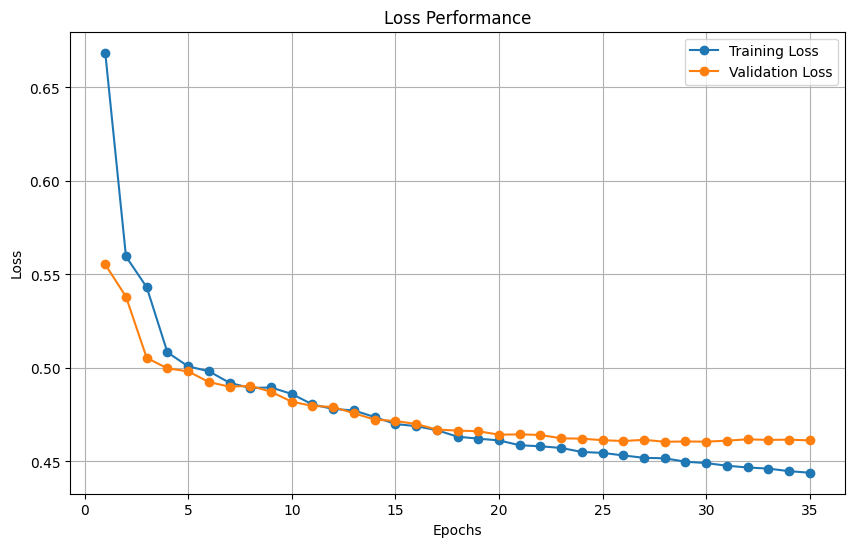

In [70]:
#Make graph of validation loss over epochs of final random seed
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label="Training Loss", marker="o")
plt.plot(epochs, val_losses, label="Validation Loss", marker="o")

plt.title("Loss Performance")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

The first version of this graph with 50 epochs showed that my model started to overfit and increase loss on the validation set around epoch 35 so that is where I decided to cut off my model

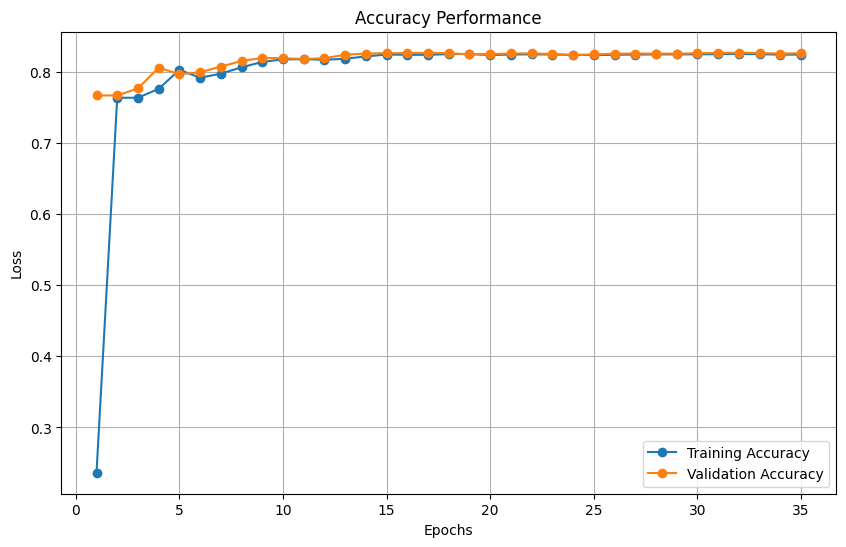

In [71]:
#Make graph of validation accuracy over epochs of final random seed
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracies, label="Training Accuracy", marker="o")
plt.plot(epochs, val_accuracies, label="Validation Accuracy", marker="o")

plt.title("Accuracy Performance")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

The almost instant jump to near maximum accuracy throughout all epochs is very interesting. Considering that low 80% accuracy has been what nearly all my models have been able to achieve at best this suggests there is a pattern in the data that is either too complex to accurately interpret or that it is almost randomness along a certain dimension of the data that is causing the models to be inable to predict along it and miss the same points nearly every time.

Finally lets look at how the model performs on our test set. Given the consistency so far I would expect it to be very similar to the validation set.

In [72]:
model, train_losses, train_accuracies, test_losses, test_accuracies, y_pred = train_simple_model(X_traint, y_traint, X_testt, y_testt, np.arange(1,11,1))

Epoch [10/35], Train Loss: 0.4910, Train Accuracy: 0.8198, Test Loss: 0.4871, Test Accuracy: 0.8232
Epoch [20/35], Train Loss: 0.4739, Train Accuracy: 0.8226, Test Loss: 0.4760, Test Accuracy: 0.8263
Epoch [30/35], Train Loss: 0.4654, Train Accuracy: 0.8246, Test Loss: 0.4709, Test Accuracy: 0.8258


Epoch [10/35], Train Loss: 0.4907, Train Accuracy: 0.8031, Test Loss: 0.4914, Test Accuracy: 0.8165
Epoch [20/35], Train Loss: 0.4754, Train Accuracy: 0.8211, Test Loss: 0.4782, Test Accuracy: 0.8227
Epoch [30/35], Train Loss: 0.4666, Train Accuracy: 0.8239, Test Loss: 0.4716, Test Accuracy: 0.8252


Epoch [10/35], Train Loss: 0.4914, Train Accuracy: 0.8198, Test Loss: 0.4867, Test Accuracy: 0.8236
Epoch [20/35], Train Loss: 0.4730, Train Accuracy: 0.8228, Test Loss: 0.4760, Test Accuracy: 0.8248
Epoch [30/35], Train Loss: 0.4638, Train Accuracy: 0.8239, Test Loss: 0.4702, Test Accuracy: 0.8257


Epoch [10/35], Train Loss: 0.4843, Train Accuracy: 0.8184, Test Loss: 0.4797, Test Accuracy: 0

In [73]:
print("Test Accuracy:", accuracy_score(y_test, y_pred)) 
print("Classification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.8259383143924128
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.89    114293
           1       0.69      0.45      0.55     34591

    accuracy                           0.83    148884
   macro avg       0.77      0.70      0.72    148884
weighted avg       0.81      0.83      0.81    148884



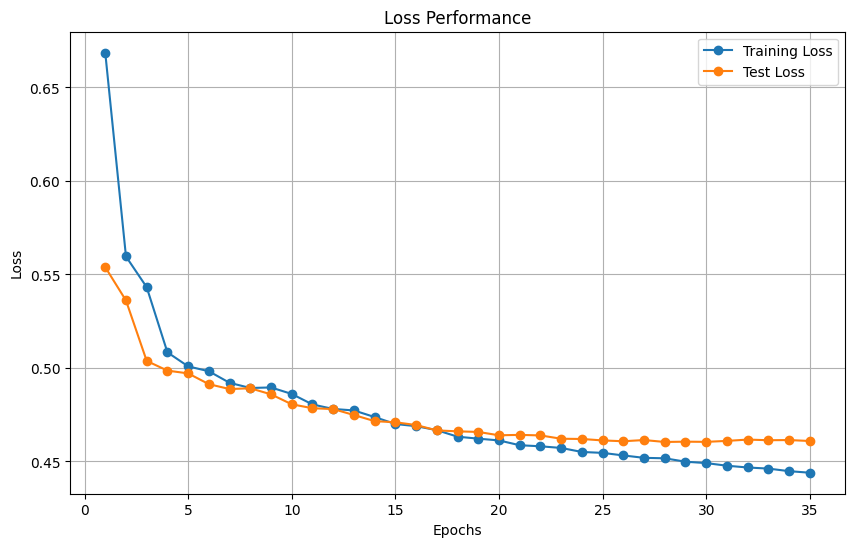

In [74]:
#Make graph of validation loss over epochs of final random seed
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label="Training Loss", marker="o")
plt.plot(epochs, test_losses, label="Test Loss", marker="o")

plt.title("Loss Performance")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

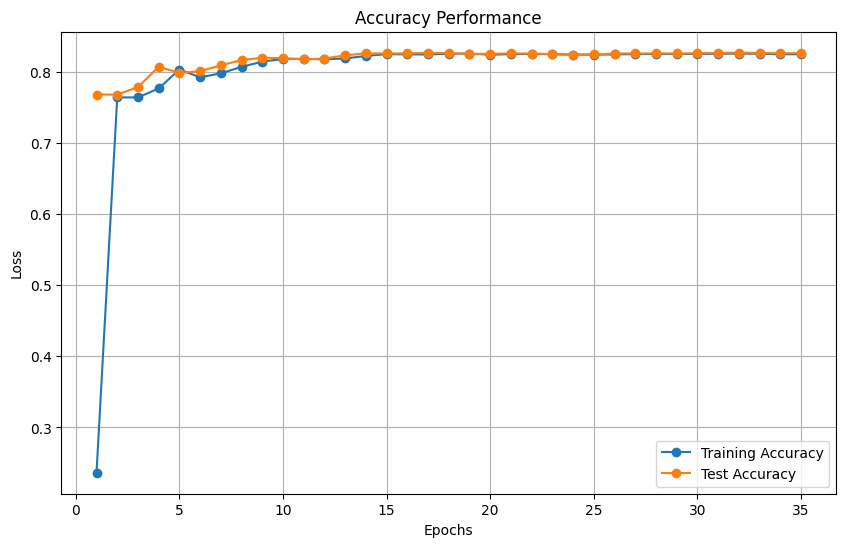

In [75]:
#Make graph of validation accuracy over epochs of final random seed
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracies, label="Training Accuracy", marker="o")
plt.plot(epochs, test_accuracies, label="Test Accuracy", marker="o")

plt.title("Accuracy Performance")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Once again as expected my neural network performs nearly identically on the test set as it did to the validation set.